In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('cofee_shop_sales.csv')

df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [11]:
filter_tea = df[df['product_category'].str.contains('Tea', case=False, na=False)]

product_category_tea = filter_tea['product_category'].unique()
product_type_tea = filter_tea['product_type'].unique()
product_detail_tea = filter_tea['product_detail'].unique()

print(product_category_tea)
print(product_type_tea)
print(product_detail_tea)

<StringArray>
['Tea', 'Loose Tea']
Length: 2, dtype: str
<StringArray>
[  'Brewed Chai tea',  'Brewed Black tea',  'Brewed Green tea',
 'Brewed herbal tea',        'Herbal tea',          'Chai tea',
         'Green tea',         'Black tea']
Length: 8, dtype: str
<StringArray>
[ 'Spicy Eye Opener Chai Lg',  'Spicy Eye Opener Chai Rg',
              'Earl Grey Lg',     'Serenity Green Tea Lg',
            'Lemon Grass Rg',            'Lemon Grass Lg',
             'Peppermint Lg',   'Morning Sunrise Chai Rg',
   'Morning Sunrise Chai Lg',             'Peppermint Rg',
      'English Breakfast Rg',     'Serenity Green Tea Rg',
 'Traditional Blend Chai Lg',              'Earl Grey Rg',
      'English Breakfast Lg', 'Traditional Blend Chai Rg',
                'Peppermint',      'Morning Sunrise Chai',
        'Serenity Green Tea',    'Traditional Blend Chai',
     'Spicy Eye Opener Chai',         'English Breakfast',
               'Lemon Grass',                 'Earl Grey']
Length: 24, dt

In [ ]:
# Menggabungkan child menjadi string yang dipisahkan koma
group_by_type = filter_tea.groupby('product_type')['product_detail'].unique().reset_index()

# Opsional: Jika ingin menggabungkannya jadi satu teks (string)
group_by_type['product_detail'] = group_by_type['product_detail'].apply(lambda x: ", ".join(x))

group_by_type.to_csv('products_tea.csv', index=False)
print(group_by_type)


        product_type                                     product_detail
0          Black tea                       English Breakfast, Earl Grey
1   Brewed Black tea  Earl Grey Lg, English Breakfast Rg, Earl Grey ...
2    Brewed Chai tea  Spicy Eye Opener Chai Lg, Spicy Eye Opener Cha...
3   Brewed Green tea       Serenity Green Tea Lg, Serenity Green Tea Rg
4  Brewed herbal tea  Lemon Grass Rg, Lemon Grass Lg, Peppermint Lg,...
5           Chai tea  Morning Sunrise Chai, Traditional Blend Chai, ...
6          Green tea                                 Serenity Green Tea
7         Herbal tea                            Peppermint, Lemon Grass


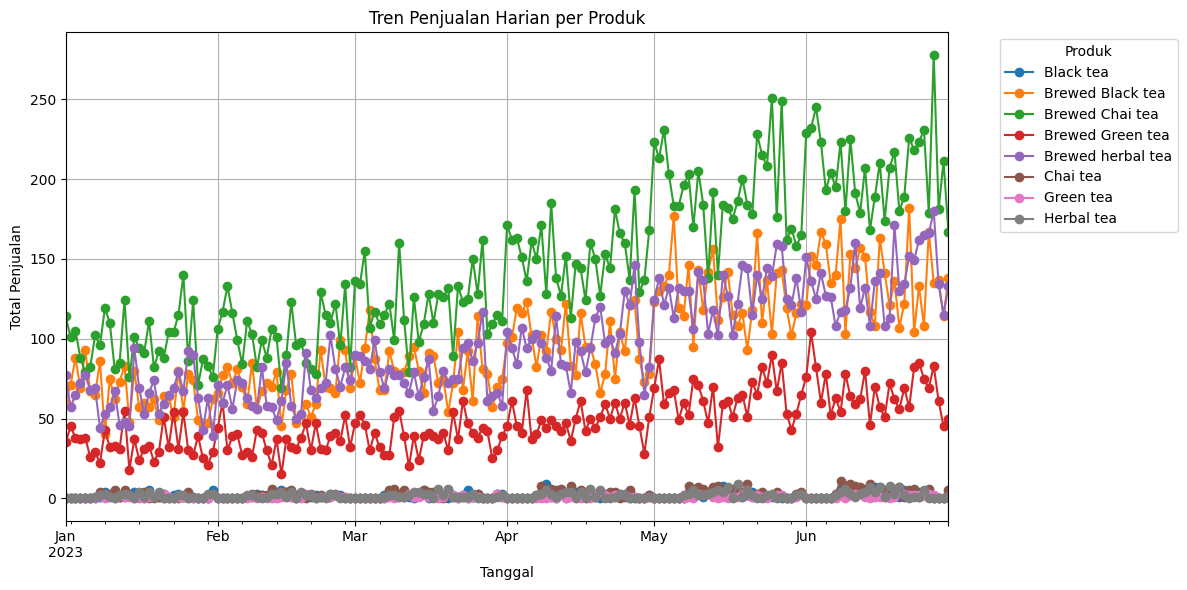

In [18]:
import matplotlib.pyplot as plt

# 2. Pastikan kolom tanggal adalah format datetime
filter_tea['transaction_date'] = pd.to_datetime(filter_tea['transaction_date'])

# 3. Membuat Pivot Table
# Index: Tanggal (sumbu X)
# Columns: Nama produk (tiap produk jadi satu garis)
# Values: Jumlah penjualan (sumbu Y)
pivot_df = filter_tea.pivot_table(index='transaction_date', 
                          columns='product_type', 
                          values='transaction_qty', 
                          aggfunc='sum').fillna(0)

# 4. Membuat Grafik
pivot_df.plot(kind='line', marker='o', figsize=(12, 6))

plt.title('Tren Penjualan Harian per Produk')
plt.xlabel('Tanggal')
plt.ylabel('Total Penjualan')
plt.legend(title='Produk', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [21]:
df_product_types = pd.read_csv('product_types.csv')

df_product_types.head(10)

,product_name,qty
0,Brewed Black tea,1000 ml
1,Black tea,250 g
2,Brewed Green tea,1000 ml
3,Green tea,250 g
4,Brewed Chai tea,1000 ml
5,Chai tea,250 g
6,Brewed Herbal tea,1000 ml
7,Herbal tea,250 g


In [3]:
import pandas as pd

# Contoh dataframe
df = pd.read_csv('cofee_shop_sales.csv')

# Mengelompokkan produk menjadi list per store_id
df_grouped = df.groupby('store_id')['product_detail'].apply(list).reset_index()

print(df_grouped)

   store_id                                     product_detail
0         3  [Our Old Time Diner Blend Sm, Latte, Croissant...
1         5  [Ethiopia Rg, Spicy Eye Opener Chai Lg, Dark c...
2         8  [Lemon Grass Rg, Dark chocolate Lg, Sustainabl...


In [4]:
# Mengelompokkan store_id menjadi list untuk setiap produk
product_map = df.groupby('product_detail')['store_id'].apply(list).reset_index()

# Jika ingin daftar toko yang unik saja (tidak double jika produk muncul berkali-kali di satu toko)
product_map_unique = df.groupby('product_detail')['store_id'].apply(lambda x: list(set(x))).reset_index()

print(product_map_unique)

                  product_detail   store_id
0               Almond Croissant  [8, 3, 5]
1            Brazilian - Organic  [8, 3, 5]
2                   Brazilian Lg  [8, 3, 5]
3                   Brazilian Rg  [8, 3, 5]
4                   Brazilian Sm  [8, 3, 5]
..                           ...        ...
75  Sustainably Grown Organic Lg  [8, 3, 5]
76  Sustainably Grown Organic Rg  [8, 3, 5]
77        Traditional Blend Chai  [8, 3, 5]
78     Traditional Blend Chai Lg  [8, 3, 5]
79     Traditional Blend Chai Rg  [8, 3, 5]

[80 rows x 2 columns]
